In [4]:
import pandas as pd
import numpy as np
import scipy.sparse as sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import json

In [ ]:
dfMovies = pd.read_csv("ml-32m/movies.csv")
dfRatings = pd.read_csv("ml-32m/ratings.csv")

dfTest = dfRatings.groupby('userId').sample(frac=0.2, random_state=42)

dfTrain = dfRatings.drop(dfTest.index)

print(f"Train shape: {dfTrain.shape}")
print(f"Test shape: {dfTest.shape}")

Train shape: (25601239, 4)
Test shape: (6398965, 4)


In [ ]:


users = pd.Categorical(dfTrain['userId'])
movies = pd.Categorical(dfTrain['movieId'])

U = sparse.csr_matrix((dfTrain['rating'], (users.codes, movies.codes)))

print('Utility matrix shape: %s' % str(U.shape))

test_users = pd.Categorical(dfTest['userId'])


Utility matrix shape: (200948, 80255)


In [ ]:

dfMovieGenres = dfMovies.set_index('movieId')['genres'].str.get_dummies()

dfMovieGenres = dfMovieGenres.reindex(index=movies.categories)

P = sparse.csr_matrix(dfMovieGenres.values)

print('U shape: %s' % str(U.shape))
print('P shape: %s' % str(P.shape))



U shape: (200948, 80255)
P shape: (80255, 20)


In [ ]:
# model 1, IMPLICIT FEEDBACK MODEL, does not take rating into account, only if the movie was seen

U_binary = (U > 0).astype(int)

UP = U_binary @ P

user_profiles_normalized = normalize(UP, norm='l2', axis=1)

P_normalized = normalize(P, norm='l2', axis=1)

print('user_profiles_normalized shape: %s' % str(user_profiles_normalized.shape))
print('P_normalized shape: %s' % str(P_normalized.shape))

user_profiles_normalized shape: (200948, 20)
P_normalized shape: (80255, 20)


In [ ]:
# model 2, Explicit FEEDBACK MODEL, takes rating into account, "mean centering"

U_centered = U.copy().astype(float)

row_sums = np.asarray(U_centered.sum(axis=1)).flatten()

row_counts = U_centered.getnnz(axis=1)

row_means = np.zeros(U_centered.shape[0])
np.divide(row_sums, row_counts, out=row_means, where=row_counts != 0)

row_indices_for_data = np.repeat(np.arange(U_centered.shape[0]), np.diff(U_centered.indptr))

U_centered.data -= row_means[row_indices_for_data]

UP = U_centered @ P

user_profiles_normalized = normalize(UP, norm='l2', axis=1)

P_normalized = normalize(P, norm='l2', axis=1)



In [ ]:
# SETUP FOR EVALUATION
# RUN BEFORE ANY EVALUATION CELL


user_id_to_index = {user_id: idx for idx, user_id in enumerate(users.categories)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movies.categories)}
index_to_movie_id = {idx: movie_id for idx, movie_id in enumerate(movies.categories)}

valid_test_df = dfTest[dfTest['movieId'].isin(movies.categories)]

test_user_items = valid_test_df.groupby('userId')['movieId'].apply(set).to_dict()

K = 5
precisions = []

np.random.seed(42)
sample_users = np.random.choice(list(test_user_items.keys()), size=1000, replace=False)

In [ ]:
# constructing a popularity mask

ratings_per_movie = dfRatings['movieId'].value_counts()

popular_movie_ids = set(ratings_per_movie[ratings_per_movie > 1000].index)

unpopular_mask = np.array([
    (index_to_movie_id[idx] not in popular_movie_ids)
    for idx in range(len(movies.categories))
])

In [ ]:
# CONTROL data to compare against

for user_id in sample_users:
    if user_id not in user_id_to_index:
        continue
        
    user_idx = user_id_to_index[user_id]
    
    actual_test_movies = test_user_items[user_id]

    if len(actual_test_movies) == 0:
        continue
    
    predicted_scores = np.random.random(P.shape[0])
    
    seen_in_train_indices = U_binary[user_idx].indices
    predicted_scores[seen_in_train_indices] = -np.inf
    
    top_k_indices = np.argsort(predicted_scores)[-K:][::-1]
    
    top_k_movie_ids = set([index_to_movie_id[idx] for idx in top_k_indices])
    
    hits = len(top_k_movie_ids.intersection(actual_test_movies))
    
    user_precision = hits / K

    precisions.append(user_precision)

print(f"Average Precision@{K} with random recommendations: {np.mean(precisions):.4f}")

Average Precision@5: 0.0006


In [ ]:
# EVALUATION for the implicit and explicit feedback models
# just run the cell corresponding to desired model above to initialize the UP matrix
# also make sure to run cell for popularity mask

precisions = []

for user_id in sample_users:
    if user_id not in user_id_to_index:
        continue
        
    user_idx = user_id_to_index[user_id]
    
    actual_test_movies = test_user_items[user_id]

    if len(actual_test_movies) == 0:
        continue
    
    predicted_scores = user_profiles_normalized[user_idx, :] @ P_normalized.T
    predicted_scores = predicted_scores.toarray().flatten()
    
    seen_in_train_indices = U_binary[user_idx].indices
    predicted_scores[seen_in_train_indices] = -np.inf

    predicted_scores[unpopular_mask] = -np.inf
    
    top_k_indices = np.argsort(predicted_scores)[-K:][::-1]
    
    top_k_movie_ids = set([index_to_movie_id[idx] for idx in top_k_indices])
    
    hits = len(top_k_movie_ids.intersection(actual_test_movies))
    
    user_precision = hits / K

    precisions.append(user_precision)

print(f"Average Precision@{K}: {np.mean(precisions):.4f}")

Average Precision@5: 0.0054


In [ ]:
# EVALUATION of explicit model, comparing popularity cutoffs

cutoff_points = [0, 1000, 5000, 10000, 25000, 35000, 50000, 70000, 100000, 500000]

cutoff_masks = {}
for cutoff in cutoff_points:
    valid_ids = set(ratings_per_movie[ratings_per_movie >= cutoff].index)
    cutoff_masks[cutoff] = np.array([
        (index_to_movie_id[idx] not in valid_ids)
        for idx in range(len(movies.categories))
    ])
 
results_dict = {cutoff: {'precisions': []} for cutoff in cutoff_points}

print(f"Evaluating Explicit Feedback Model at K={K} across {len(cutoff_points)} cutoffs...")

for user_id in sample_users:
    if user_id not in user_id_to_index:
        continue
        
    user_idx = user_id_to_index[user_id]
    actual_test_movies = test_user_items[user_id]
    
    if len(actual_test_movies) == 0:
        continue
    
    raw_scores = user_profiles_normalized[user_idx, :] @ P_normalized.T
    raw_scores = raw_scores.toarray().flatten()
    
    seen_in_train_indices = U_binary[user_idx].indices

    for cutoff in cutoff_points:
        predicted_scores = raw_scores.copy()
        
        predicted_scores[seen_in_train_indices] = -np.inf
        
        predicted_scores[cutoff_masks[cutoff]] = -np.inf
        
        top_k_indices = np.argsort(predicted_scores)[-K:][::-1]
        top_k_movie_ids = set([index_to_movie_id[idx] for idx in top_k_indices])
        
        hits = len(top_k_movie_ids.intersection(actual_test_movies))
        results_dict[cutoff]['precisions'].append(hits / K)

summary_data = []
for cutoff in cutoff_points:
    avg_p = np.mean(results_dict[cutoff]['precisions'])
    summary_data.append({
        'Min Ratings Cutoff': cutoff,
        f'Precision@{K}': avg_p,
    })

df_results = pd.DataFrame(summary_data)
print(df_results.to_string(index=False))

Evaluating Explicit Feedback Model at K=5 across 10 cutoffs...

--- Popularity Cutoff Evaluation Results ---
 Min Ratings Cutoff  Precision@5
                  0       0.0054
               1000       0.0128
               5000       0.0302
              10000       0.0506
              25000       0.0956
              35000       0.1186
              50000       0.1620
              70000       0.1586
             100000       0.0458
             500000       0.0162


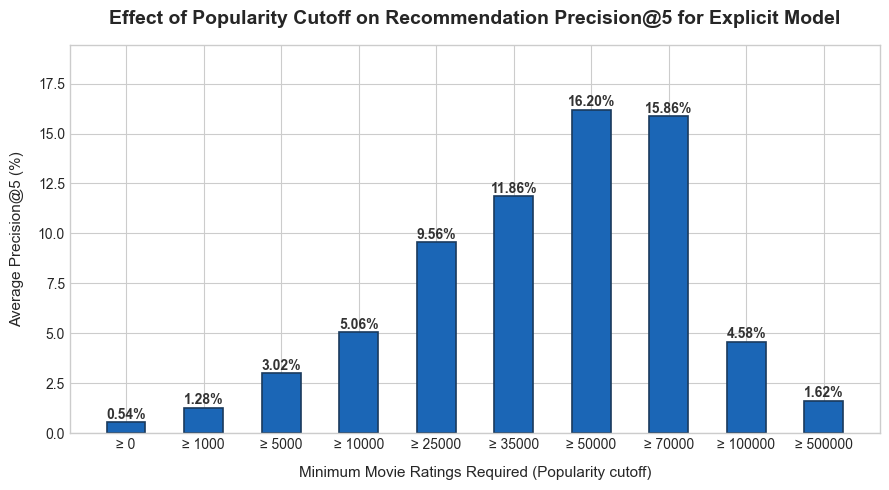

In [ ]:
# plot the precision comparing the explicit model with different popularity cutoffs

plt.figure(figsize=(9, 5))

cutoffs_str = [f"≥ {c}" for c in df_results['Min Ratings Cutoff']]
precision_scores = df_results[f'Precision@{K}'] * 100  

bars = plt.bar(cutoffs_str, precision_scores, color="#1b66b6", width=0.5, edgecolor='#1a3a5c', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.02,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

plt.title(f'Effect of Popularity Cutoff on Recommendation Precision@{K} for Explicit Model', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Minimum Movie Ratings Required (Popularity cutoff)', fontsize=11, labelpad=10)
plt.ylabel(f'Average Precision@{K} (%)', fontsize=11, labelpad=10)
plt.ylim(0, max(precision_scores) * 1.2)  # Leave headroom for labels

plt.tight_layout()
plt.show()

In [ ]:
# precomputing recommendations for interactive webapp
# just make sure that unpopular_mask value is set to desired cutoff in previous cell

# restrict searchable movies so hat the app is lightweight
searchable_movie_ids = ratings_per_movie[ratings_per_movie > 100].index

movie_id_to_title = dfMovies.set_index('movieId')['title'].to_dict()

recommendations_json = {}

for movie_id in searchable_movie_ids:
    if movie_id not in movie_id_to_index:
        continue
        
    movie_idx = movie_id_to_index[movie_id]
    movie_title = movie_id_to_title[movie_id]
    
    current_movie_vector = P_normalized[movie_idx]
    
    similarity_scores = (current_movie_vector @ P_normalized.T).toarray().flatten()
    
    similarity_scores[movie_idx] = -np.inf

    similarity_scores[unpopular_mask] = -np.inf
    
    top_5_indices = np.argsort(similarity_scores)[-5:][::-1]
    
    recommended_titles = [movie_id_to_title[index_to_movie_id[idx]] for idx in top_5_indices]
    
    recommendations_json[movie_title] = recommended_titles

with open("content-based-recommendations.json", "w") as f:
    json.dump(recommendations_json, f, indent=2)

print(f"Done! Saved recommendations for {len(recommendations_json)} movies.")

Done! Saved recommendations for 12141 movies.
